# 1. Khai báo thư viện

In [1]:
import os
import json
import shutil
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# 2. Đọc dữ liệu

In [2]:
PROCESSED_DIR = r"D:/21013345/21013345/DCCS/dataset/processed_mp"
LABEL_JSON = r"D:/21013345/21013345/DCCS/dataset/class_labels.json"
OUTPUT_MODEL_KERAS = r"D:/21013345/21013345/DCCS/dataset/sign_language_model.keras"
OUTPUT_MODEL_H5 = r"D:/21013345/21013345/DCCS/dataset/sign_language_model.h5"

# 3. Cấu hình

In [3]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 40
TEST_SIZE = 0.2
RANDOM_STATE = 42

In [4]:
AUG_PARAMS = dict(
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1,
    zoom_range=0.2,
    brightness_range=(0.7, 1.3),
    horizontal_flip=True,
    fill_mode="reflect"
)

# 4. Chia dữ liệu thành train_test_split

In [5]:
print("Splitting train/test...")
train_dir = os.path.join(PROCESSED_DIR, "train")
test_dir = os.path.join(PROCESSED_DIR, "test")

if os.path.exists(train_dir): shutil.rmtree(train_dir)
if os.path.exists(test_dir): shutil.rmtree(test_dir)
os.makedirs(train_dir)
os.makedirs(test_dir)

Splitting train/test...


In [6]:
for label in os.listdir(PROCESSED_DIR):
    class_dir = os.path.join(PROCESSED_DIR, label)
    if not os.path.isdir(class_dir) or label in ["train", "test"]:
        continue
    files = [f for f in os.listdir(class_dir) if f.lower().endswith((".jpg", ".png"))]
    train_files, test_files = train_test_split(files, test_size=TEST_SIZE, random_state=RANDOM_STATE)
    os.makedirs(os.path.join(train_dir, label), exist_ok=True)
    os.makedirs(os.path.join(test_dir, label), exist_ok=True)
    for f in train_files:
        shutil.copy(os.path.join(class_dir, f), os.path.join(train_dir, label, f))
    for f in test_files:
        shutil.copy(os.path.join(class_dir, f), os.path.join(test_dir, label, f))

print("Dataset split completed.")

Dataset split completed.


# 6. Data augmentation + Data generator

In [7]:
train_datagen = ImageDataGenerator(rescale=1./255, **AUG_PARAMS)
test_datagen = ImageDataGenerator(rescale=1./255)

In [8]:
train_gen = train_datagen.flow_from_directory(train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
                                              class_mode='categorical', shuffle=True)

Found 73600 images belonging to 39 classes.


In [9]:
test_gen = test_datagen.flow_from_directory(test_dir, target_size=IMG_SIZE, batch_size=1,
                                            class_mode='categorical', shuffle=False)

Found 18400 images belonging to 39 classes.


# 7. Lưu lables

In [10]:
with open(LABEL_JSON, "w", encoding="utf-8") as f:
    json.dump(train_gen.class_indices, f, indent=4, ensure_ascii=False)
print("Saved class_labels.json")

Saved class_labels.json


# 8. Xây dựng mô hình CNN

In [11]:
num_classes = train_gen.num_classes

In [12]:
def build_model(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), n_classes=num_classes):
    inp = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(n_classes, activation='softmax')(x)
    return models.Model(inputs=inp, outputs=out)

In [13]:
model = build_model()
model.compile(optimizer=Adam(learning_rate=5e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 39)             │        20,007 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 228,807 (893.78 KB)

 Trainable params: 227,143 (887.28 KB)

 Non-trainable params: 1,664 (6.50 KB)

# 9. Callbacks

In [14]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.5, min_lr=1e-6, verbose=1),
    ModelCheckpoint(OUTPUT_MODEL_KERAS, monitor='val_accuracy', save_best_only=True, verbose=1)
]

# 10. Train model

In [15]:
print("Training started...")
history = model.fit(train_gen, validation_data=test_gen, epochs=EPOCHS, callbacks=callbacks)
print("Training complete.")

Training started...
Epoch 1/40


c:\Users\NPDiu\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:120: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


2300/2300 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - accuracy: 0.2249 - loss: 3.0719
Epoch 1: val_accuracy improved from -inf to 0.65440, saving model to D:/21013345/21013345/DCCS/dataset/sign_language_model.keras
2300/2300 ━━━━━━━━━━━━━━━━━━━━ 613s 265ms/step - accuracy: 0.2250 - loss: 3.0715 - val_accuracy: 0.6544 - val_loss: 1.0855 - learning_rate: 5.0000e-04
Epoch 2/40
2300/2300 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - accuracy: 0.6896 - loss: 0.9576
Epoch 2: val_accuracy improved from 0.65440 to 0.88000, saving model to D:/21013345/21013345/DCCS/dataset/sign_language_model.keras
2300/2300 ━━━━━━━━━━━━━━━━━━━━ 614s 267ms/step - accuracy: 0.6896 - loss: 0.9575 - val_accuracy: 0.8800 - val_loss: 0.3695 - learning_rate: 5.0000e-04
Epoch 3/40
2300/2300 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.8380 - loss: 0.5136
Epoch 3: val_accuracy improved from 0.88000 to 0.91685, saving model to D:/21013345/21013345/DCCS/dataset/sign_language_model.keras
2300/2300 ━━━━━━━━━━━━━━━━━━━━ 595s 259ms/step

# 11. Save models in both formats

In [16]:
model.save(OUTPUT_MODEL_KERAS)
model.save(OUTPUT_MODEL_H5)
print("Models saved")

Models saved


# 12. Evaluate and plot

In [17]:
print("Evaluating...")
y_true = test_gen.classes
y_pred = np.argmax(model.predict(test_gen, verbose=1), axis=1)
labels = list(train_gen.class_indices.keys())

Evaluating...
18400/18400 ━━━━━━━━━━━━━━━━━━━━ 123s 7ms/step


In [18]:
print("Evaluating on test set...")
y_true = test_gen.classes
y_pred = np.argmax(model.predict(test_gen, verbose=1), axis=1)
labels = list(train_gen.class_indices.keys())
print(classification_report(y_true, y_pred, target_names=labels))

Evaluating on test set...
18400/18400 ━━━━━━━━━━━━━━━━━━━━ 138s 8ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       100
           2       1.00      1.00      1.00       100
           3       1.00      1.00      1.00       100
           4       1.00      0.91      0.95       100
           5       1.00      1.00      1.00       100
           6       0.90      1.00      0.95       100
           7       1.00      0.99      0.99       100
           8       1.00      0.99      0.99       100
           9       1.00      1.00      1.00       100
           A       1.00      1.00      1.00       600
           B       1.00      1.00      1.00       600
           C       1.00      1.00      1.00       600
           D       1.00      1.00      1.00       600
           E       1.00      1.00      1.00       600
           F       1.00      1.00      1.00       600
        

<Figure size 1200x1000 with 0 Axes>

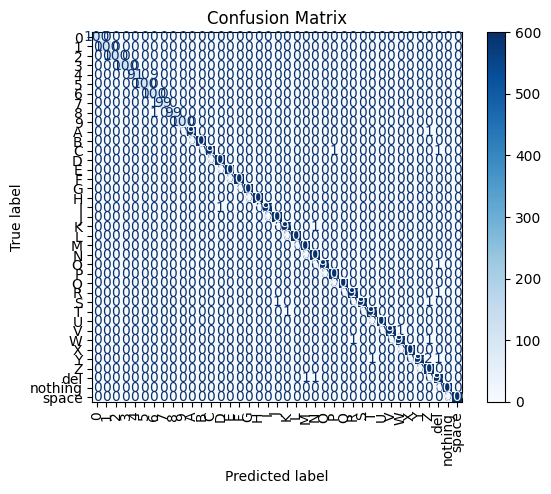

In [19]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12,10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(xticks_rotation='vertical', cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.show()

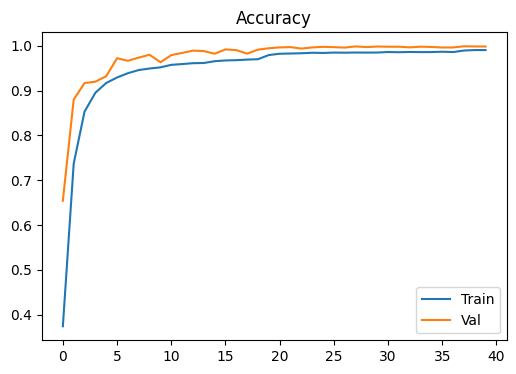

In [20]:
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.legend(); plt.title("Accuracy"); plt.show()

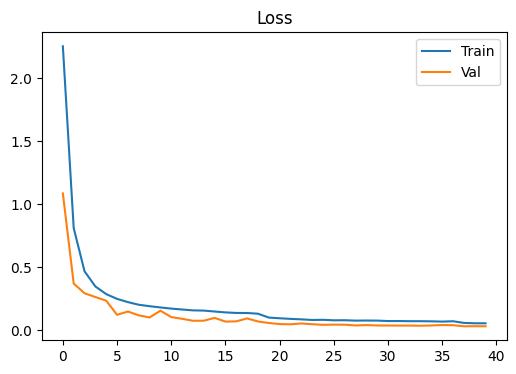

In [21]:
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.legend(); plt.title("Loss"); plt.show()